# Brain Tumor MRI - Exploratory Data Analysis (EDA)

## Overview
This notebook explores the Brain Tumor MRI dataset before building any models.
The goal is to understand the data structure, class distribution, image sizes 
and potential preprocessing challenges. 

## Dataset
- **Source:** Kaggle - Brain Tumor MRI Dataset by masoudnickparvar
- **Classes:** Glioma, Meningioma, No Tumor, Pituitary
- **Training images:** 5600 (1400 per class)
- **Testing images:** 1600 (400 per class)

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
import random


In [2]:
train_dir = "../data/Training"
test_dir = "../data/Testing"

classes = os.listdir(train_dir)
print("Classes:", classes)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## Class Distribution
Counting images per class in the training set to check for class imbalance.

In [3]:
for cls in classes:
    path = os.path.join(train_dir, cls)
    count = len(os.listdir(path))
    print(f"{cls}: {count} images")
    

glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images


## Sample Images
Visualizing one sample image per class to see the visual differences 
between tumor types.

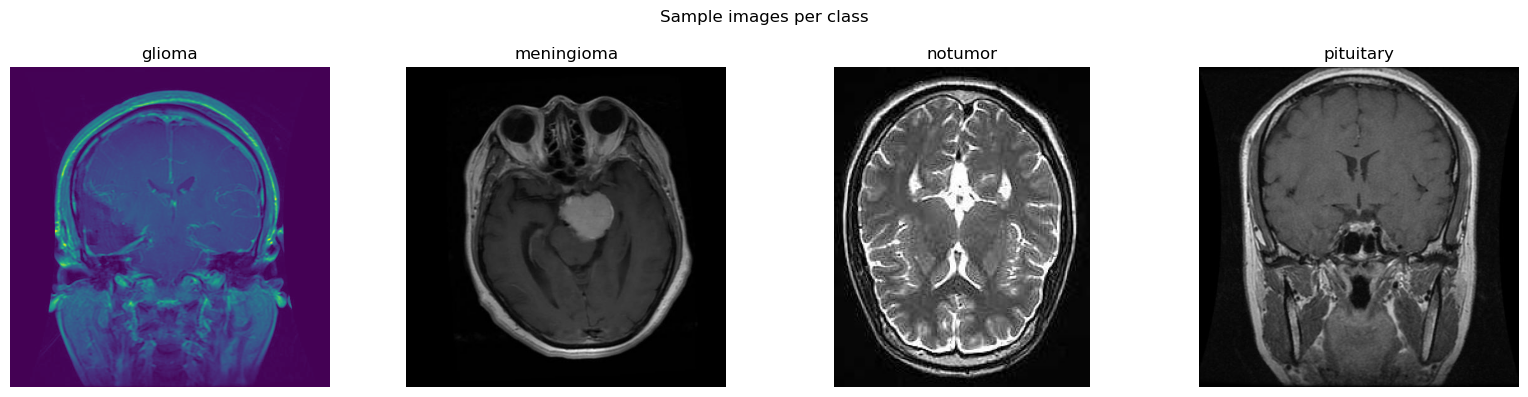

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, cls in enumerate(classes):
    path = os.path.join(train_dir, cls)
    img_file = os.listdir(path)[0]
    img = mpimg.imread(os.path.join(path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.suptitle("Sample images per class")
plt.tight_layout()
plt.show()

## Image Properties
Checking image sizes and color channels. This revealed two important 
preprocessing challenges:
- Images have different sizes → need to resize to 224x224
- Some images are grayscale, others RGB → need to convert all to RGB

In [ ]:
for cls in classes:
    path = os.path.join(train_dir, cls)
    img_file = random.choice(os.listdir(path))
    img = mpimg.imread(os.path.join(path, img_file))
    print(f"{cls}: {img.shape}")

glioma: (512, 512, 3)
meningioma: (512, 512, 3)
notumor: (326, 276, 3)
pituitary: (512, 512)


## Test Set Verification
Confirming the test set has the same balanced structure as training data.

In [6]:
test_classes = os.listdir(test_dir)
print("Test classes:", test_classes)

for cls in test_classes:
    path = os.path.join(test_dir, cls)
    count = len(os.listdir(path))
    print(f"{cls}: {count} images")

Test classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
glioma: 400 images
meningioma: 400 images
notumor: 400 images
pituitary: 400 images
